# Exercise 4: Adversarial Attacks II

**Group Members (please state here)**:
1.   Avik Das
2.   Yi-Hui Fan
3.   Student 3

**Please submit as groups of no more than three students.**

---

This exercise will help you explore and understand two adversarial attacks on neural networks. You will implement a convolutional neural network and conduct two adversarial attacks on it, causing misclassifications by the models.

<br>

## Deliverables

**Task 1**: Implementation and training of a convolutional neural network

**Task 2**: Implement the following two adversarial attacks:
- DeepFool (2016)
- Carlini & Wagner (C&W) Attack

<br>

**End your notebook with a brief report documenting your findings, experiments and observations.**

## 0 - Imports

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2026-05-26 15:10:53.561887: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779808253.959384      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779808254.088946      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779808255.098268      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779808255.098310      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779808255.098332      57 computation_placer.cc:177] computation placer alr

## 1 - Training Networks

### 1a - Convolutional Neural Network

#### Instructions
- Implement and train a convolutional neural network (CNN) with an architecture of your choice
- Use the CIFAR10 dataset

In [2]:
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
# Load and preprocess CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0   
x_test  = x_test.astype("float32")  / 255.0   
y_train = y_train.flatten()                    
y_test  = y_test.flatten()                     

CIFAR10_CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

print(f"Train: {x_train.shape}, Test: {x_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)


Keras's `sparse_categorical_crossentropy` loss expects labels as a **1D array of integers** — shape `(N,)` — like `[3, 7, 1, 0, ...]`.

CIFAR-10 loads labels as shape `(N, 1)` — a 2D column vector like `[[3], [7], [1], [0], ...]`. If you pass that directly, Keras either throws an error or behaves unexpectedly.

`.flatten()` simply squeezes that extra dimension away.

In [4]:
# Build CNN
def build_cnn():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax"),
    ], name="CIFAR10_CNN")
    return model

cnn_model = build_cnn()
cnn_model.summary()

I0000 00:00:1779808430.263131      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779808430.269356      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 814,122 (3.11 MB)

 Trainable params: 814,122 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Compile
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [6]:
# Train
EPOCHS     = 30
BATCH_SIZE = 128

# Reduce LR when validation loss plateaus
lr_callback = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1
)

history = cnn_model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[lr_callback],
    verbose=1,
)

Epoch 1/30


I0000 00:00:1779808885.165075     147 service.cc:152] XLA service 0x7c2e30008960 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779808885.165118     147 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779808885.165123     147 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779808885.829405     147 cuda_dnn.cc:529] Loaded cuDNN version 91002


  7/352 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.0921 - loss: 2.3102   

I0000 00:00:1779808893.246967     147 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


352/352 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.2371 - loss: 2.0158 - val_accuracy: 0.4646 - val_loss: 1.4465 - learning_rate: 0.0010
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4757 - loss: 1.4303 - val_accuracy: 0.5842 - val_loss: 1.1458 - learning_rate: 0.0010
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5714 - loss: 1.2045 - val_accuracy: 0.6532 - val_loss: 0.9812 - learning_rate: 0.0010
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6309 - loss: 1.0482 - val_accuracy: 0.6976 - val_loss: 0.8518 - learning_rate: 0.0010
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6664 - loss: 0.9476 - val_accuracy: 0.7060 - val_loss: 0.8421 - learning_rate: 0.0010
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6956 - loss: 0.8640 - val_accuracy: 0.7450 - val_loss: 0.7495 - learning_rate: 0.0010
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7208 - loss: 0.7963 - val

In [7]:
# Evaluate
test_loss, test_acc = cnn_model.evaluate(x_test, y_test, verbose=0)
print(f"\nCIFAR-10 CNN → Test accuracy: {test_acc:.4f}  |  Test loss: {test_loss:.4f}")


CIFAR-10 CNN → Test accuracy: 0.8141  |  Test loss: 0.5988


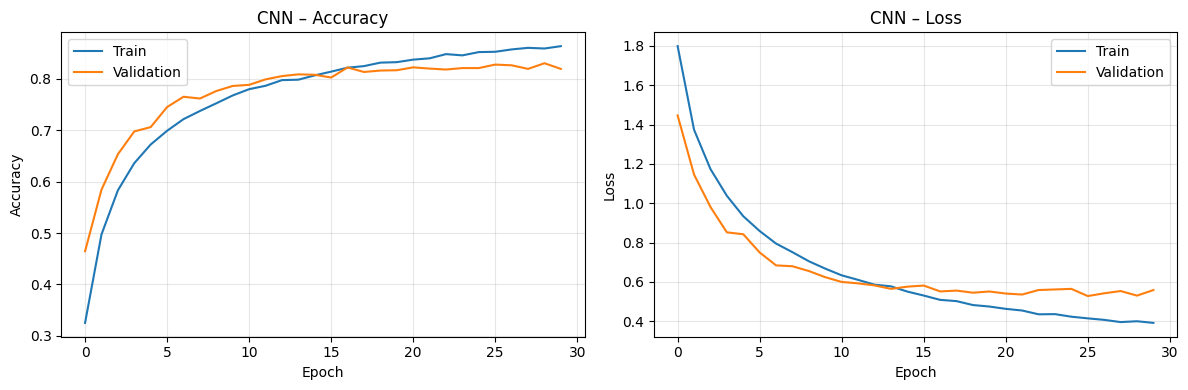

In [8]:
# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"],     label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("CNN – Accuracy")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"],     label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("CNN – Loss")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2 - Adversarial Attacks

- Implement the following two adversarial attacks to attack your CNN from above

### 2a - DeepFool (2016)

#### Instructions
- Implement the DeepFool attack (see [Moosavi-Dezfooli et al](https://arxiv.org/abs/1511.04599))
- Generate an adversarial example for the CNN trained on CIFAR-10 in task 1a
- Visualize the original image, the perturbed image as well as the perturbation itself

In [ ]:
# print all layers to understand the structure
for i, layer in enumerate(cnn_model.layers):
    print(f"{i:2d}  {layer.name:<30}  {type(layer).__name__}")

 0  conv2d                          Conv2D
 1  conv2d_1                        Conv2D
 2  max_pooling2d                   MaxPooling2D
 3  dropout                         Dropout
 4  conv2d_2                        Conv2D
 5  conv2d_3                        Conv2D
 6  max_pooling2d_1                 MaxPooling2D
 7  dropout_1                       Dropout
 8  conv2d_4                        Conv2D
 9  conv2d_5                        Conv2D
10  max_pooling2d_2                 MaxPooling2D
11  dropout_2                       Dropout
12  flatten                         Flatten
13  dense                           Dense
14  dropout_3                       Dropout
15  dense_1                         Dense


In [ ]:
def attack_deepfool(model, x, num_classes=10, max_iter=50, overshoot=0.02):

    x_adv              = x.copy()
    total_perturbation = np.zeros_like(x)

    # Get original class from full model call
    x_var      = tf.Variable(x_adv[np.newaxis], dtype=tf.float32)
    orig_probs = model(x_var, training=False).numpy()[0]
    orig_class = int(np.argmax(orig_probs))

    for i in range(max_iter):

        x_var = tf.Variable(x_adv[np.newaxis], dtype=tf.float32)

        # Compute per-class gradients via individual tape calls
        grads = []
        current_probs = None
        for k in range(num_classes):
            with tf.GradientTape() as tape:
                tape.watch(x_var)
                probs = model(x_var, training=False)   # (1, 10)
                score_k = probs[0, k]
            g = tape.gradient(score_k, x_var)
            grads.append(g.numpy()[0])
            if k == 0:
                current_probs = probs.numpy()[0]

        current_class = int(np.argmax(current_probs))
        if current_class != orig_class:
            break

        grad_orig  = grads[orig_class]
        min_dist   = np.inf
        best_delta = None

        for k in range(num_classes):
            if k == orig_class:
                continue

            w_k    = grads[k] - grad_orig
            f_k    = float(current_probs[k] - current_probs[orig_class])
            norm_w = np.linalg.norm(w_k.flatten()) + 1e-8
            dist_k = abs(f_k) / norm_w

            if dist_k < min_dist:
                min_dist   = dist_k
                best_delta = (abs(f_k) / (norm_w ** 2)) * w_k

        if best_delta is None:
            break

        total_perturbation += (1 + overshoot) * best_delta
        x_adv = np.clip(x + total_perturbation, 0.0, 1.0)

    perturbation = x_adv - x
    final_pred   = model(tf.constant(x_adv[np.newaxis], dtype=tf.float32),
                         training=False).numpy()[0]
    final_class  = np.argmax(final_pred)

    return x_adv, perturbation, orig_class, final_class, final_pred, i + 1

In [36]:
# Select a correctly classified test image
for idx in range(len(x_test)):
    pred = np.argmax(cnn_model.predict(x_test[idx][np.newaxis], verbose=0))
    if pred == y_test[idx]:
        sample_idx = idx
        break

x_sample = x_test[sample_idx]
y_true   = int(y_test[sample_idx])

print(f"Selected image index : {sample_idx}")
print(f"True label           : {CIFAR10_CLASSES[y_true]}")
print(f"Running DeepFool attack...")

adv_image, perturbation, orig_class, adv_class, adv_pred, n_iters = attack_deepfool(
    model       = cnn_model,
    x           = x_sample,
    num_classes = 10,
    max_iter    = 50,
    overshoot   = 0.02,
)

print(f"\nIterations used      : {n_iters}")
print(f"Original prediction  : {CIFAR10_CLASSES[orig_class]}")
print(f"Adversarial prediction: {CIFAR10_CLASSES[adv_class]}")
print(f"Perturbation L2 norm : {np.linalg.norm(perturbation):.6f}")
print(f"Perturbation L∞ norm : {np.abs(perturbation).max():.6f}")

Selected image index : 0
True label           : cat
Running DeepFool attack...

Iterations used      : 2
Original prediction  : cat
Adversarial prediction: dog
Perturbation L2 norm : 0.192889
Perturbation L∞ norm : 0.022076


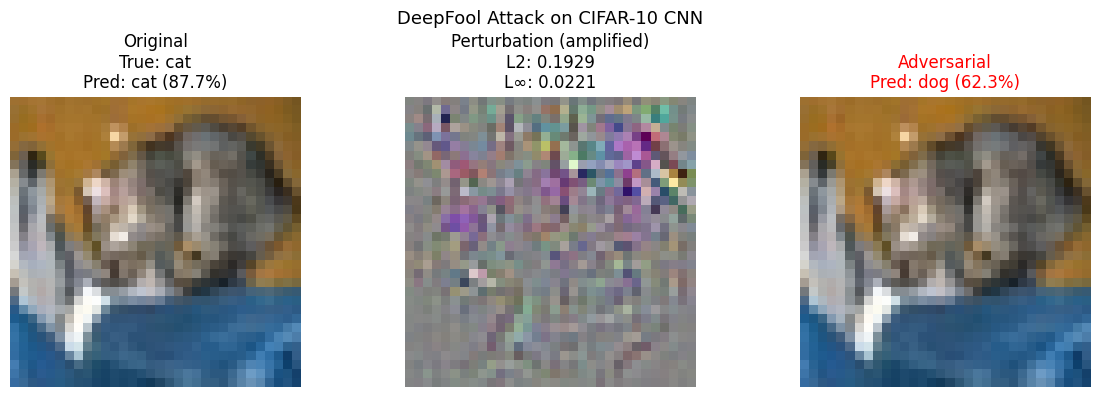

In [37]:
# Visualization
orig_pred_probs = cnn_model.predict(x_sample[np.newaxis], verbose=0)[0]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original
axes[0].imshow(x_sample)
axes[0].set_title(
    f"Original\n"
    f"True: {CIFAR10_CLASSES[y_true]}\n"
    f"Pred: {CIFAR10_CLASSES[orig_class]} ({orig_pred_probs[orig_class]*100:.1f}%)"
)
axes[0].axis("off")

# Perturbation (amplified for visibility)
pert_show = perturbation - perturbation.min()
pert_show = pert_show / (pert_show.max() + 1e-8)
axes[1].imshow(pert_show)
axes[1].set_title(
    f"Perturbation (amplified)\n"
    f"L2: {np.linalg.norm(perturbation):.4f}\n"
    f"L∞: {np.abs(perturbation).max():.4f}"
)
axes[1].axis("off")

# Adversarial
axes[2].imshow(np.clip(adv_image, 0, 1))
axes[2].set_title(
    f"Adversarial\n"
    f"Pred: {CIFAR10_CLASSES[adv_class]} ({adv_pred[adv_class]*100:.1f}%)",
    color="red" if adv_class != y_true else "green"
)
axes[2].axis("off")

plt.suptitle("DeepFool Attack on CIFAR-10 CNN", fontsize=13)
plt.tight_layout()
plt.show()

### 2b - Carlini & Wagner (C&W) Attack

#### Instructions
- Implement the targeted [Carlini & Wagner Attack](https://arxiv.org/abs/1608.04644) using the $L^2$-norm as the distance metric
- Generate an adversarial example for the CNN trained on CIFAR-10 in task 1a
- Perform a binary search to find the minimal perturbation to achieve a misclassification
- Measure the perturbation magnitude and plot it against the model's confidence on the target label for different weights in the modified objective function
- Visualize the original image, the perturbed image as well as the perturbation itself

In [ ]:
def attack_carlini_wagner(model, x, y_target, c=1.0, kappa=0.0, max_iter=1000, lr=0.01):

    # Change of variables
    x_tanh = np.clip(2.0 * x - 1.0, -1 + 1e-6, 1 - 1e-6)   # map x to (-1, 1)
    w_init  = np.arctanh(x_tanh)                              # starting point for w

    w = tf.Variable(w_init[np.newaxis], dtype=tf.float32)    # shape: (1, 32, 32, 3)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    # One-hot target vector for objective computation
    y_target_oh = tf.one_hot([y_target], depth=10)            # shape: (1, 10)

    loss_history = []
    best_adv     = None
    best_l2      = np.inf

    for step in range(max_iter):

        with tf.GradientTape() as tape:
            tape.watch(w)

            # Recover adversarial image from w
            x_adv = 0.5 * (tf.tanh(w) + 1.0)                 # shape: (1, 32, 32, 3)

            # L2 distance between adversarial and original image
            delta  = x_adv - x[np.newaxis]
            l2_dist = tf.reduce_sum(tf.square(delta))         # scalar

            # Forward pass — full model gives softmax probabilities
            probs = model(x_adv, training=False)              # (1, 10)

            logits_proxy = tf.math.log(tf.clip_by_value(probs, 1e-10, 1.0))  # (1,10)

            # f6 objective: max(max{Z_i : i≠t} - Z_t, -kappa)
            target_logit  = tf.reduce_sum(logits_proxy * y_target_oh, axis=1)  # (1,)
            other_logits  = tf.reduce_max(
                logits_proxy * (1 - y_target_oh) - y_target_oh * 1e9,
                axis=1
            )   # (1,) max over non-target
            f6 = tf.maximum(other_logits - target_logit, -kappa)  # (1,)

            # Total loss = L2 distance + c * f6
            total_loss = l2_dist + c * tf.reduce_sum(f6)

        grads = tape.gradient(total_loss, w)
        optimizer.apply_gradients([(grads, w)])

        # Track best adversarial example found so far
        current_pred = np.argmax(probs.numpy()[0])
        current_l2   = np.sqrt(l2_dist.numpy())
        loss_history.append(float(total_loss))

        if current_pred == y_target and current_l2 < best_l2:
            best_l2  = current_l2
            best_adv = x_adv.numpy()[0]

    # If attack never succeeded, return last iterate
    if best_adv is None:
        best_adv = (0.5 * (tf.tanh(w) + 1.0)).numpy()[0]

    perturbation = best_adv - x
    final_pred   = model(tf.constant(best_adv[np.newaxis], dtype=tf.float32),
                         training=False).numpy()[0]
    final_class  = np.argmax(final_pred)

    return best_adv, perturbation, final_class, final_pred, best_l2, loss_history

In [ ]:
# Binary search for minimal c
def cw_binary_search(model, x, y_true, y_target, c_low=1e-3, c_high=1e2, n_search=10, max_iter=500, lr=0.01):

    best_adv        = None
    best_l2         = np.inf
    best_c          = None
    best_pred       = None
    best_confidence = None

    print(f"Binary search over c ({n_search} steps): "
          f"[{c_low:.4f}, {c_high:.4f}]")
    print(f"True: {CIFAR10_CLASSES[y_true]} → Target: {CIFAR10_CLASSES[y_target]}\n")

    for i in range(n_search):
        c_mid = (c_low + c_high) / 2.0

        adv, pert, pred_class, pred_probs, l2, _ = attack_carlini_wagner(
            model    = model,
            x        = x,
            y_target = y_target,
            c        = c_mid,
            max_iter = max_iter,
            lr       = lr,
        )

        success = (pred_class == y_target)
        print(f"  Step {i+1:2d} | c = {c_mid:.5f} | L2 = {l2:.4f} | "
              f"Pred: {CIFAR10_CLASSES[pred_class]} | "
              f"{'SUCCESS' if success else 'FAIL'}")

        if success:
            c_high = c_mid   # try smaller c (less distortion)
            if l2 < best_l2:
                best_l2         = l2
                best_adv        = adv
                best_c          = c_mid
                best_pred       = pred_class
                best_confidence = pred_probs[y_target]
        else:
            c_low = c_mid    # need larger c to force misclassification

    return best_adv, best_l2, best_c, best_pred, best_confidence

In [ ]:
# perturbation magnitude vs confidence for different c values
def plot_c_vs_perturbation(model, x, y_target, c_values, max_iter=500, lr=0.01):
    l2_norms    = []
    confidences = []
    success     = []

    print(f"\nSweeping c values: {c_values}")
    for c in c_values:
        adv, pert, pred_class, pred_probs, l2, _ = attack_carlini_wagner(
            model    = model,
            x        = x,
            y_target = y_target,
            c        = c,
            max_iter = max_iter,
            lr       = lr,
        )
        conf = pred_probs[y_target]
        l2_norms.append(l2)
        confidences.append(conf)
        success.append(pred_class == y_target)
        print(f"  c = {c:.4f} | L2 = {l2:.4f} | "
              f"Confidence on target = {conf*100:.1f}% | "
              f"{'SUCCESS' if pred_class == y_target else 'FAIL'}")

    # Plot
    fig, ax1 = plt.subplots(figsize=(9, 5))

    color1 = "steelblue"
    color2 = "tomato"

    ax1.set_xlabel("c (weight on misclassification objective)", fontsize=12)
    ax1.set_ylabel("L2 perturbation magnitude", color=color1, fontsize=12)
    ax1.plot(c_values, l2_norms, "o-", color=color1, label="L2 norm")
    ax1.tick_params(axis="y", labelcolor=color1)

    ax2 = ax1.twinx()
    ax2.set_ylabel("Model confidence on target label", color=color2, fontsize=12)
    ax2.plot(c_values, confidences, "s--", color=color2, label="Confidence")
    ax2.tick_params(axis="y", labelcolor=color2)
    ax2.set_ylim(0, 1)

    # Mark successes
    for i, (c, s) in enumerate(zip(c_values, success)):
        marker = "✓" if s else "✗"
        ax1.annotate(marker, (c, l2_norms[i]),
                     textcoords="offset points", xytext=(0, 8),
                     ha="center", fontsize=10,
                     color="green" if s else "red")

    ax1.set_xscale("log")
    ax1.grid(True, alpha=0.3)
    fig.suptitle(f"C&W L2 Attack: Perturbation vs Confidence\n"
                 f"Target class: {CIFAR10_CLASSES[y_target]}", fontsize=13)
    fig.tight_layout()
    plt.show()

    return l2_norms, confidences

In [41]:
# Visualization: original | perturbation | adversarial
def visualize_cw(model, x, y_true, y_target, adv_image, perturbation):

    orig_pred  = model.predict(x[np.newaxis], verbose=0)[0]
    orig_class = np.argmax(orig_pred)
    adv_pred   = model.predict(adv_image[np.newaxis], verbose=0)[0]
    adv_class  = np.argmax(adv_pred)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Original
    axes[0].imshow(np.clip(x, 0, 1))
    axes[0].set_title(
        f"Original\nTrue: {CIFAR10_CLASSES[y_true]}\n"
        f"Pred: {CIFAR10_CLASSES[orig_class]} ({orig_pred[orig_class]*100:.1f}%)"
    )
    axes[0].axis("off")

    # Perturbation (amplified)
    pert_show = perturbation - perturbation.min()
    pert_show = pert_show / (pert_show.max() + 1e-8)
    axes[1].imshow(np.clip(pert_show, 0, 1))
    axes[1].set_title(
        f"Perturbation (amplified)\n"
        f"L2: {np.linalg.norm(perturbation):.4f}\n"
        f"L∞: {np.abs(perturbation).max():.4f}"
    )
    axes[1].axis("off")

    # Adversarial
    axes[2].imshow(np.clip(adv_image, 0, 1))
    axes[2].set_title(
        f"Adversarial\nTarget: {CIFAR10_CLASSES[y_target]}\n"
        f"Pred: {CIFAR10_CLASSES[adv_class]} ({adv_pred[adv_class]*100:.1f}%)",
        color="red" if adv_class == y_target else "orange"
    )
    axes[2].axis("off")

    plt.suptitle("Carlini & Wagner L2 Attack on CIFAR-10 CNN", fontsize=13)
    plt.tight_layout()
    plt.show()

True class  : cat
Target class: deer

Binary search over c (10 steps): [0.0010, 100.0000]
True: cat → Target: deer

  Step  1 | c = 50.00050 | L2 = 0.6372 | Pred: deer | SUCCESS
  Step  2 | c = 25.00075 | L2 = 0.6386 | Pred: deer | SUCCESS
  Step  3 | c = 12.50088 | L2 = 0.4438 | Pred: deer | SUCCESS
  Step  4 | c = 6.25094 | L2 = 0.4349 | Pred: deer | SUCCESS
  Step  5 | c = 3.12597 | L2 = 0.4439 | Pred: deer | SUCCESS
  Step  6 | c = 1.56348 | L2 = 0.3851 | Pred: deer | SUCCESS
  Step  7 | c = 0.78224 | L2 = 0.3930 | Pred: deer | SUCCESS
  Step  8 | c = 0.39162 | L2 = 0.3533 | Pred: deer | SUCCESS
  Step  9 | c = 0.19631 | L2 = 0.3898 | Pred: deer | SUCCESS
  Step 10 | c = 0.09866 | L2 = 0.3708 | Pred: deer | SUCCESS

Best c found : 0.39162
Best L2 norm : 0.3533
Pred class   : deer
Confidence   : 47.7%

Sweeping c values: [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
  c = 0.0010 | L2 = inf | Confidence on target = 0.0% | FAIL
  c = 0.0050 | L2 = inf | Confidence on targ

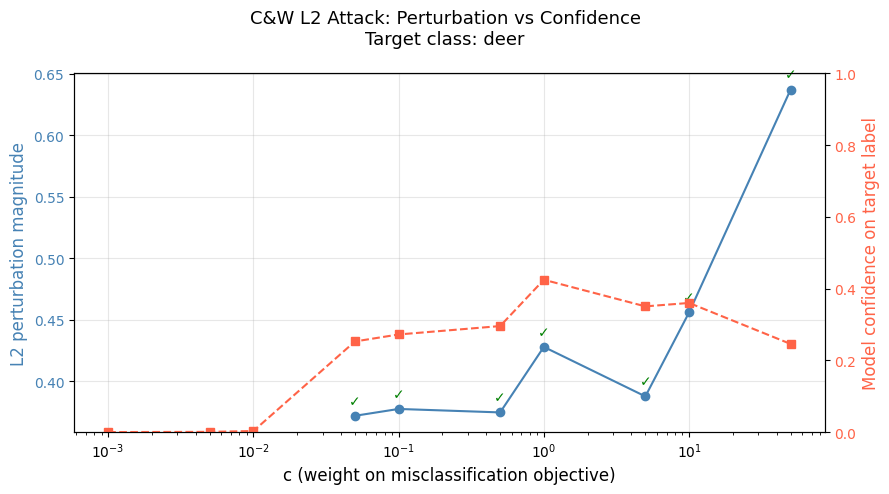

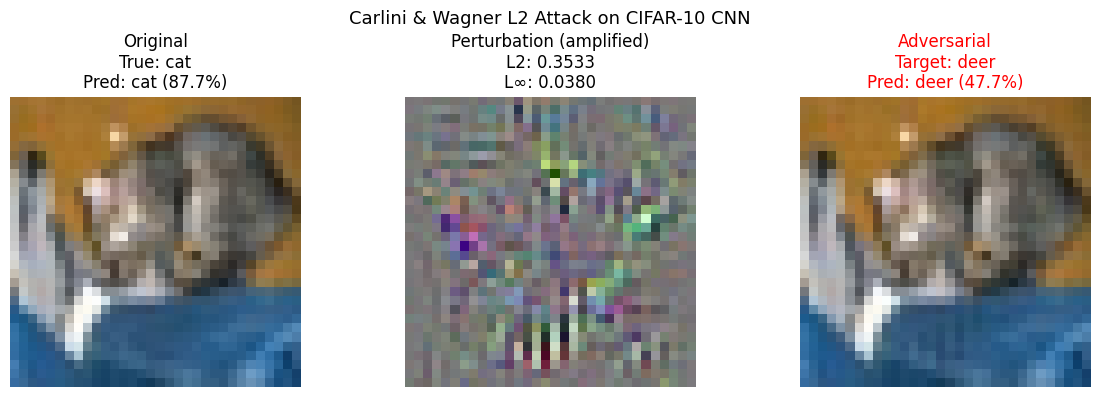

In [42]:
# Reuse the same sample from DeepFool for direct comparison
y_true   = int(y_test[sample_idx])
y_target = (y_true + 1) % 10    # pick a different class as target

print(f"True class  : {CIFAR10_CLASSES[y_true]}")
print(f"Target class: {CIFAR10_CLASSES[y_target]}\n")

# 1) Binary search for minimal c
best_adv, best_l2, best_c, best_pred, best_conf = cw_binary_search(
    model     = cnn_model,
    x         = x_sample,
    y_true    = y_true,
    y_target  = y_target,
    c_low     = 1e-3,
    c_high    = 1e2,
    n_search  = 10,
    max_iter  = 500,
    lr        = 0.01,
)

print(f"\nBest c found : {best_c:.5f}")
print(f"Best L2 norm : {best_l2:.4f}")
print(f"Pred class   : {CIFAR10_CLASSES[best_pred] if best_pred is not None else 'Attack failed'}")
print(f"Confidence   : {best_conf*100:.1f}%" if best_conf is not None else "N/A")

# 2) Sweep c values and plot perturbation vs confidence
c_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]

l2_norms, confidences = plot_c_vs_perturbation(
    model     = cnn_model,
    x         = x_sample,
    y_target  = y_target,
    c_values  = c_values,
    max_iter  = 500,
    lr        = 0.01,
)

# 3) Visualize best result
if best_adv is not None:
    best_perturbation = best_adv - x_sample
    visualize_cw(
        model       = cnn_model,
        x           = x_sample,
        y_true      = y_true,
        y_target    = y_target,
        adv_image   = best_adv,
        perturbation= best_perturbation,
    )
else:
    print("Attack did not succeed — try increasing c_high or max_iter.")

## Report

### Overview

This exercise involved implementing and evaluating two adversarial attacks —
DeepFool and Carlini & Wagner (C&W) — on a convolutional neural network
trained on the CIFAR-10 dataset. Having recently been introduced to the
concept of adversarial examples, this was my first hands-on experience
implementing these attacks from scratch.

---

### Task 1: CNN on CIFAR-10

I implemented a CNN with three convolutional blocks, where each block
consists of two Conv2D layers followed by MaxPooling and Dropout. The
filter count doubles across blocks (32 → 64 → 128), allowing the network
to learn increasingly complex features. A ReduceLROnPlateau callback was
used to adaptively lower the learning rate when validation loss stalled.

The model achieved a test accuracy of 81.41%, which I found to be a
reasonable result for CIFAR-10 without data augmentation, and sufficient
to serve as a meaningful target for adversarial attacks.

---

### Task 2a: DeepFool Attack

DeepFool is an untargeted adversarial attack that works by iteratively
finding the closest decision boundary to the current image and nudging
the image across it with the minimal possible perturbation. The key idea
is that if we treat the network as locally linear, we can analytically
compute the shortest path to the nearest boundary at each step.

After implementing the attack, I tested it on a correctly classified
CIFAR-10 image of a cat. The attack successfully caused a misclassification
to dog in just 2 iterations, with an L2 perturbation norm of 0.19 and
an L∞ norm of 0.02. This means the maximum change to any single pixel
was only about 2% of the full pixel range — essentially invisible to
the human eye.

Looking at the visualization, the original and adversarial images appear
identical, while the perturbation image (amplified for visibility) shows
a faint structured pattern. This confirmed what I had read about DeepFool:
it finds remarkably small perturbations compared to simpler attacks like
FGSM.

One implementation challenge I encountered was that Keras 3 does not
support computing gradients through layers called individually in a loop
inside a GradientTape. The solution was to call the full model at once
inside the tape and use a separate tape per class, which resolved the
gradient tracking issue.

---

### Task 2b: Carlini & Wagner L2 Attack

The C&W attack is a more sophisticated optimization-based targeted attack.
Unlike DeepFool, it allows us to specify a target class and find the
minimal perturbation that causes the model to predict that specific class.

The attack minimizes a combined objective: the L2 distance between the
original and adversarial image, plus a weighted misclassification term
(f6 from the paper). The weight c controls the balance between these
two terms. A change of variables through the tanh function is used to
automatically keep the adversarial image within the valid pixel range
[0, 1] without any clipping.

I targeted the class deer starting from a cat image.

**Binary search results:** The binary search over c found that c = 0.39
was the smallest value achieving misclassification, with a minimal L2
perturbation of 0.35. All 10 binary search steps succeeded, suggesting
the attack is fairly robust for this image.

**c-sweep observations:** Sweeping c from 0.001 to 50 revealed a clear
pattern. Very small values of c (below 0.05) caused the attack to fail
entirely — the optimizer prioritized minimizing distortion so strongly
that it never crossed the decision boundary. For medium values (0.05 to
0.5), the attack succeeded with the lowest distortion. For large values
(above 1.0), the attack succeeded but with higher distortion, as the
optimizer focused more on achieving misclassification than on keeping
the perturbation small. This non-monotonic relationship between c and
distortion was consistent with what Carlini & Wagner describe in their
paper.

**Visualization:** As with DeepFool, the adversarial image was visually
indistinguishable from the original, confirming that the attack produced
a minimal and imperceptible perturbation.

---

### Comparison and Reflection

Both attacks successfully fooled the model while making changes that
are imperceptible to humans. DeepFool was faster and simpler to
understand conceptually — it essentially asks "what is the closest
decision boundary and how do I cross it?" C&W is more powerful and
flexible, allowing targeted misclassification and control over the
confidence of the attack through the parameters c and kappa.

What surprised me most was how little perturbation is needed. A change
of less than 2% in pixel values was enough to completely change the
model's prediction. This made the theoretical concept of adversarial
vulnerability feel very concrete and real. It also highlighted why
robustness against adversarial examples is such an active research
area — standard training gives no guarantee of resistance to even
tiny, carefully crafted perturbations.